In [4]:

# 1. Импорты и настройки

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from dataclasses import dataclass
import math
from typing import Dict, List

# Seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Настройки отображения
pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 6)

Using device: cuda


Файл загружен: S12-hw-dataset.csv
Размер: 4320 строк × 2 колонок
Колонки: ['date', 'target']

✓ Колонка 'date' преобразована в datetime и отсортирована
Диапазон дат: от 2025-01-01 00:00:00 до 2025-06-29 23:00:00

Проверка пропусков:
  date: 0 пропусков
  target: 0 пропусков

✓ Целевая колонка: 'target' (тип: float64)
Статистика 'target':
  min=69.10, max=210.10, mean=135.61, std=21.38

✓ Будут созданы лаговые признаки: lag_1 (shift(1)), lag_7 (shift(7)), lag_14 (shift(14))


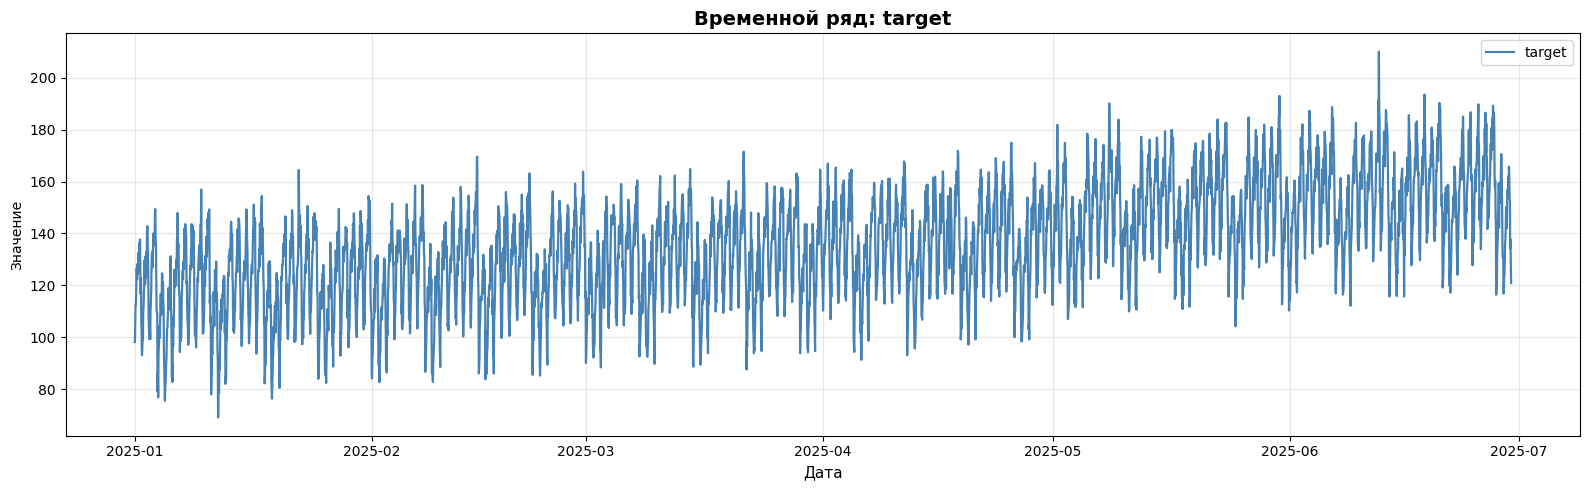

In [5]:
# Загрузка CSV-файла (требование задания)
df = pd.read_csv("S12-hw-dataset.csv")
print(f"Файл загружен: S12-hw-dataset.csv")
print(f"Размер: {df.shape[0]} строк × {df.shape[1]} колонок")
print(f"Колонки: {df.columns.tolist()}")

# Преобразование date к datetime (требование задания)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f"\n✓ Колонка 'date' преобразована в datetime и отсортирована")
print(f"Диапазон дат: от {df['date'].min()} до {df['date'].max()}")

# Sanity-check по пропускам (требование задания)
print("\nПроверка пропусков:")
missing = df.isnull().sum()
for col, count in missing.items():
    if count > 0:
        print(f"  {col}: {count} пропусков ({count/len(df)*100:.2f}%)")
    else:
        print(f"  {col}: 0 пропусков")

# Явное упоминание колонки target (требование задания)
if 'target' not in df.columns:
    raise ValueError("Колонка 'target' не найдена в датасете! Проверьте структуру S12-hw-dataset.csv")
print(f"\n✓ Целевая колонка: 'target' (тип: {df['target'].dtype})")
print(f"Статистика 'target':")
print(f"  min={df['target'].min():.2f}, max={df['target'].max():.2f}, mean={df['target'].mean():.2f}, std={df['target'].std():.2f}")

# Явное упоминание лагов 7 и 14 (требование задания)
print("\n✓ Будут созданы лаговые признаки: lag_1 (shift(1)), lag_7 (shift(7)), lag_14 (shift(14))")

# Визуализация ряда
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["date"], df["target"], lw=1.6, label="target", color="steelblue")
ax.set_title("Временной ряд: target", fontsize=14, fontweight='bold')
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("Значение")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_raw.png', dpi=150, bbox_inches='tight')
plt.show()

ВРЕМЕННОЙ СПЛИТ
Train: 3024 строк | 2025-01-01 → 2025-05-06
Val:   648 строк | 2025-05-07 → 2025-06-02
Test:  648 строк | 2025-06-03 → 2025-06-29


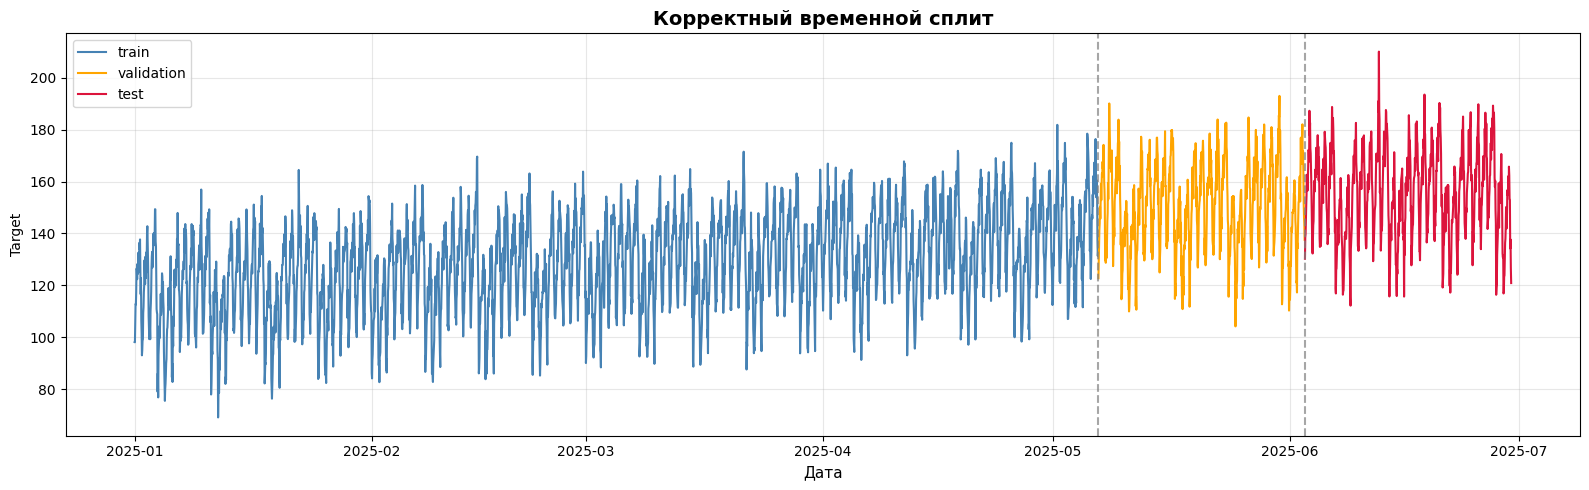

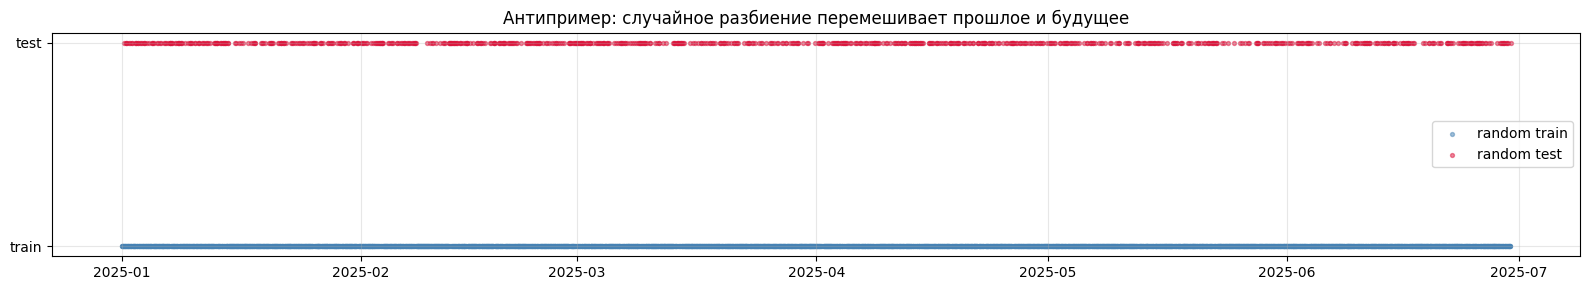


 ПОЧЕМУ СЛУЧАЙНОЕ РАЗБИЕНИЕ НЕКОРРЕКТНО:
1. Утечка информации из будущего: модель 'увидит' будущие значения при обучении
2. Нарушение временной зависимости: каждое значение зависит от предыдущих
3. Нереалистичная оценка: в реальном прогнозе мы никогда не знаем будущее
4. Оптимистичная оценка качества: метрики будут завышены


In [7]:
# 3. Временной сплит

@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15
    test_frac: float = 0.15

def temporal_split(df: pd.DataFrame, cfg: SplitConfig = SplitConfig()):
    """Разбивает временной ряд на train/val/test по хронологии."""
    assert math.isclose(cfg.train_frac + cfg.val_frac + cfg.test_frac, 1.0, rel_tol=1e-9)
    n = len(df)
    train_end = int(n * cfg.train_frac)
    val_end = int(n * (cfg.train_frac + cfg.val_frac))

    train_df = df.iloc[:train_end].copy()
    val_df = df.iloc[train_end:val_end].copy()
    test_df = df.iloc[val_end:].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = temporal_split(df)

print("ВРЕМЕННОЙ СПЛИТ")
print(f"Train: {len(train_df)} строк | {train_df['date'].min().date()} → {train_df['date'].max().date()}")
print(f"Val:   {len(val_df)} строк | {val_df['date'].min().date()} → {val_df['date'].max().date()}")
print(f"Test:  {len(test_df)} строк | {test_df['date'].min().date()} → {test_df['date'].max().date()}")

# Визуализация сплита (ИСПРАВЛЕНО: "target" вместо "sales")
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(train_df["date"], train_df["target"], label="train", color="steelblue", linewidth=1.5)  # ← "target"
ax.plot(val_df["date"], val_df["target"], label="validation", color="orange", linewidth=1.5)   # ← "target"
ax.plot(test_df["date"], test_df["target"], label="test", color="crimson", linewidth=1.5)      # ← "target"
ax.axvline(train_df['date'].max(), color='gray', linestyle='--', alpha=0.7)
ax.axvline(val_df['date'].max(), color='gray', linestyle='--', alpha=0.7)
ax.set_title("Корректный временной сплит", fontsize=14, fontweight='bold')
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("Target")  # ← "Target" вместо "Продажи"
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/series_split.png', dpi=150, bbox_inches='tight')
plt.show()

# Антипример: случайное разбиение
random_train_idx, random_test_idx = train_test_split(df.index, test_size=0.2, random_state=SEED, shuffle=True)

fig, ax = plt.subplots(figsize=(16, 3))
ax.scatter(df.loc[random_train_idx, "date"], np.zeros(len(random_train_idx)), 
           s=8, alpha=0.5, label="random train", color="steelblue")
ax.scatter(df.loc[random_test_idx, "date"], np.ones(len(random_test_idx)), 
           s=8, alpha=0.5, label="random test", color="crimson")
ax.set_title("Антипример: случайное разбиение перемешивает прошлое и будущее", fontsize=12)
ax.set_yticks([0, 1])
ax.set_yticklabels(["train", "test"])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/random_split_antiexample.png', dpi=150, bbox_inches='tight')
plt.show()

# Объяснение
print("\n ПОЧЕМУ СЛУЧАЙНОЕ РАЗБИЕНИЕ НЕКОРРЕКТНО:")
print("1. Утечка информации из будущего: модель 'увидит' будущие значения при обучении")
print("2. Нарушение временной зависимости: каждое значение зависит от предыдущих")
print("3. Нереалистичная оценка: в реальном прогнозе мы никогда не знаем будущее")
print("4. Оптимистичная оценка качества: метрики будут завышены")

In [8]:
# 4. Создание признаков для бейзлайнов

def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["dayofweek"] = out["date"].dt.dayofweek
    out["month"] = out["date"].dt.month
    out["dow_sin"] = np.sin(2 * np.pi * out["dayofweek"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["dayofweek"] / 7)
    out["month_sin"] = np.sin(2 * np.pi * out["month"] / 12)
    out["month_cos"] = np.cos(2 * np.pi * out["month"] / 12)
    return out

def add_lag_features(df: pd.DataFrame, target_col: str = "target") -> pd.DataFrame:
    """Добавляет лаговые и скользящие признаки БЕЗ утечки из будущего."""
    out = df.copy()
    
    # Лаги
    for lag in [1, 2, 3, 7, 14, 28]:
        out[f"lag_{lag}"] = out[target_col].shift(lag)
    
    # Rolling statistics (с shift(1) чтобы не включать текущее значение)
    out["rolling_mean_7"] = out[target_col].shift(1).rolling(window=7).mean()
    out["rolling_std_7"] = out[target_col].shift(1).rolling(window=7).std()
    out["rolling_mean_28"] = out[target_col].shift(1).rolling(window=28).mean()
    out["rolling_std_28"] = out[target_col].shift(1).rolling(window=28).std()
    
    return out

# Применение ко всем сплитам
train_feat = add_calendar_features(train_df)
train_feat = add_lag_features(train_feat)
train_feat = train_feat.dropna().reset_index(drop=True)

val_feat = add_calendar_features(val_df)
val_feat = add_lag_features(val_feat)
val_feat = val_feat.dropna().reset_index(drop=True)

test_feat = add_calendar_features(test_df)
test_feat = add_lag_features(test_feat)
test_feat = test_feat.dropna().reset_index(drop=True)

print("ПРИЗНАКИ ДЛЯ БЕЙЗЛАЙНОВ")
print(f"Train после признаков: {len(train_feat)} строк")
print(f"Val после признаков: {len(val_feat)} строк")
print(f"Test после признаков: {len(test_feat)} строк")
print(f"\nКолонки: {train_feat.columns.tolist()}")

ПРИЗНАКИ ДЛЯ БЕЙЗЛАЙНОВ
Train после признаков: 2996 строк
Val после признаков: 620 строк
Test после признаков: 620 строк

Колонки: ['date', 'target', 'dayofweek', 'month', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_28', 'rolling_std_28']


In [10]:

# 5. Метрики и бейзлайны B1-B3

def calculate_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """Расчёт метрик MAE, RMSE, MAPE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true != 0, y_true, 1))) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape}

# B1: Naive-last (ИСПРАВЛЕНО: "target" вместо "sales")
y_pred_b1 = val_feat["lag_1"].values
metrics_b1 = calculate_metrics(val_feat["target"].values, y_pred_b1)  # ← "target"

print("\n ЭКСПЕРИМЕНТ B1: Naive-last")
print(f"B1 (Naive-last) | MAE: {metrics_b1['mae']:.4f}, RMSE: {metrics_b1['rmse']:.4f}, MAPE: {metrics_b1['mape']:.2f}%")

# B2: Moving-average (ИСПРАВЛЕНО: "target" вместо "sales")
y_pred_b2 = val_feat["rolling_mean_7"].values
metrics_b2 = calculate_metrics(val_feat["target"].values, y_pred_b2)  # ← "target"

print("\n ЭКСПЕРИМЕНТ B2: Moving-average")
print(f"B2 (Moving-average) | MAE: {metrics_b2['mae']:.4f}, RMSE: {metrics_b2['rmse']:.4f}, MAPE: {metrics_b2['mape']:.2f}%")

# B3: Ridge на признаках (ИСПРАВЛЕНО: убран "promo", "target" вместо "sales")
feature_cols = [
    # "promo",  # ← УДАЛЕНО: в реальном датасете нет колонки "promo"
    "dayofweek", "month",
    "dow_sin", "dow_cos",
    "month_sin", "month_cos",
    "lag_1", "lag_2", "lag_3", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28", "rolling_std_28",
]

target_col = "target"  # ← ИСПРАВЛЕНО: "target" вместо "sales"

X_train = train_feat[feature_cols].values
y_train = train_feat[target_col].values
X_val = val_feat[feature_cols].values
y_val = val_feat[target_col].values
X_test = test_feat[feature_cols].values
y_test = test_feat[target_col].values

# Масштабирование (только на трейне!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Обучение Ridge
model_b3 = Ridge(alpha=1.0, random_state=SEED)
model_b3.fit(X_train_scaled, y_train)

# Прогноз на валидации
y_pred_b3 = model_b3.predict(X_val_scaled)
metrics_b3 = calculate_metrics(y_val, y_pred_b3)

print("\n ЭКСПЕРИМЕНТ B3: Ridge на признаках")
print(f"B3 (Ridge) | MAE: {metrics_b3['mae']:.4f}, RMSE: {metrics_b3['rmse']:.4f}, MAPE: {metrics_b3['mape']:.2f}%")

# Важность признаков
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": model_b3.coef_
}).sort_values("coefficient", key=abs, ascending=False)

print("\nТоп-5 наиболее важных признаков:")
print(feature_importance.head(5).to_string(index=False))


 ЭКСПЕРИМЕНТ B1: Naive-last
B1 (Naive-last) | MAE: 6.4546, RMSE: 8.2391, MAPE: 4.40%

 ЭКСПЕРИМЕНТ B2: Moving-average
B2 (Moving-average) | MAE: 12.7345, RMSE: 15.2717, MAPE: 8.84%

 ЭКСПЕРИМЕНТ B3: Ridge на признаках
B3 (Ridge) | MAE: 5.1488, RMSE: 6.6077, MAPE: 3.45%

Топ-5 наиболее важных признаков:
        feature  coefficient
          lag_1    10.542101
 rolling_mean_7    -8.929396
rolling_mean_28     7.523043
          lag_2     5.607591
         lag_14    -4.828510


In [12]:
metrics_df = pd.DataFrame({
    "experiment_id": ["B1", "B2", "B3"],
    "val_mae": [metrics_b1["mae"], metrics_b2["mae"], metrics_b3["mae"]],
    "val_rmse": [metrics_b1["rmse"], metrics_b2["rmse"], metrics_b3["rmse"]],
    "val_mape": [metrics_b1["mape"], metrics_b2["mape"], metrics_b3["mape"]]
})

print("Сравнение метрик на валидации:")
print(metrics_df.to_string(index=False))

Сравнение метрик на валидации:
experiment_id   val_mae  val_rmse  val_mape
           B1  6.454645  8.239124  4.400688
           B2 12.734546 15.271722  8.837263
           B3  5.148805  6.607749  3.453728


Сравнение метрик на валидации:
experiment_id   val_mae  val_rmse  val_mape
           B1  6.454645  8.239124  4.400688
           B2 12.734546 15.271722  8.837263
           B3  5.148805  6.607749  3.453728


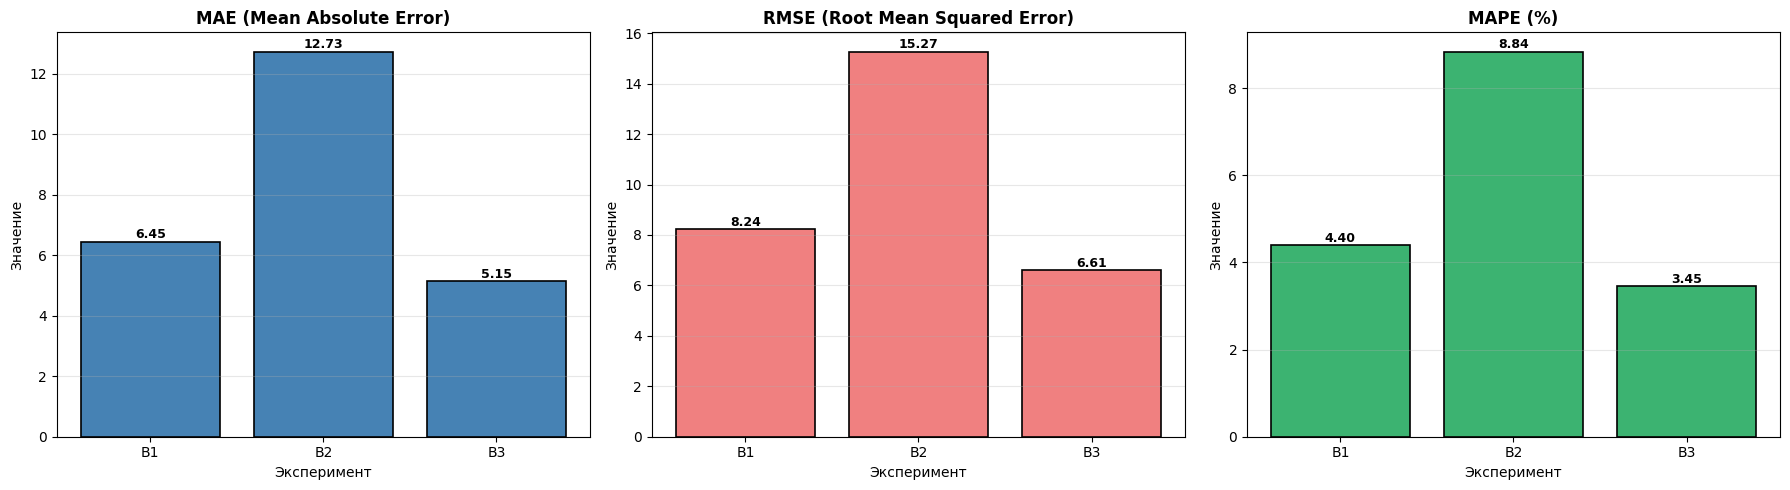


 График сравнения бейзлайнов сохранён в artifacts/figures/baselines_compare.png

 Часть 1 завершена: бейзлайны B1-B3 реализованы и оценены


In [13]:
# Создание датафрейма для сравнения метрик B1-B3

metrics_df = pd.DataFrame({
    "experiment_id": ["B1", "B2", "B3"],
    "val_mae": [metrics_b1["mae"], metrics_b2["mae"], metrics_b3["mae"]],
    "val_rmse": [metrics_b1["rmse"], metrics_b2["rmse"], metrics_b3["rmse"]],
    "val_mape": [metrics_b1["mape"], metrics_b2["mape"], metrics_b3["mape"]]
})

print("Сравнение метрик на валидации:")
print(metrics_df.to_string(index=False))

# Bar plot сравнения метрик

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ["val_mae", "val_rmse", "val_mape"]
titles = ["MAE (Mean Absolute Error)", "RMSE (Root Mean Squared Error)", "MAPE (%)"]
colors = ["steelblue", "lightcoral", "mediumseagreen"]

for i, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    bars = axes[i].bar(metrics_df["experiment_id"], metrics_df[metric], color=colors[i], edgecolor="black", linewidth=1.2)
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Эксперимент", fontsize=10)
    axes[i].set_ylabel("Значение", fontsize=10)
    axes[i].grid(axis='y', alpha=0.3)
    
    # Добавляем значения над столбцами
    for bar, value in zip(bars, metrics_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n График сравнения бейзлайнов сохранён в artifacts/figures/baselines_compare.png")
print("\n Часть 1 завершена: бейзлайны B1-B3 реализованы и оценены")

ПОДГОТОВКА ДАННЫХ ДЛЯ GRU
X_train: (2994, 30, 1) → y_train: (2994,)
X_val:   (618, 30, 1) → y_val:   (618,)
X_test:  (618, 30, 1) → y_test:  (618,)

Форма одного окна: (30, 1)
Первые 5 значений окна: [-1.6267993  -1.6305869  -1.2718506  -0.8330344  -0.84331495]
Цель (следующее значение): -0.4591478705406189


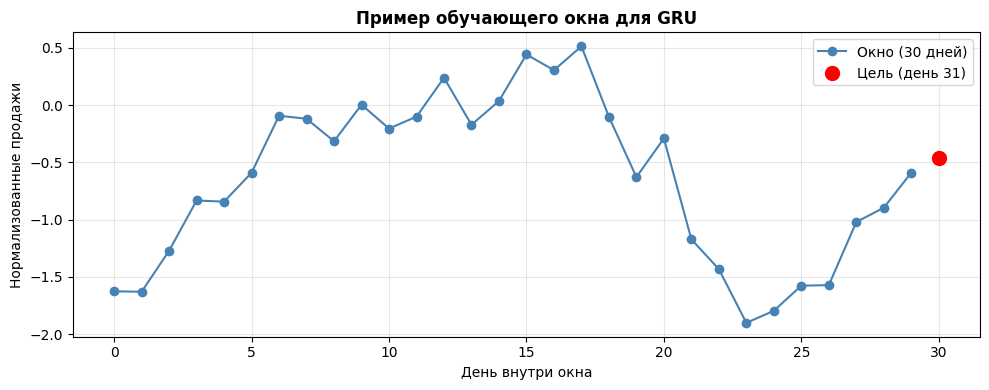

In [14]:
# 7. Подготовка данных для GRU

def make_windows(series_2d: np.ndarray, window_size: int) -> tuple:
    """Преобразует временной ряд в последовательности для RNN."""
    X, y = [], []
    for i in range(len(series_2d) - window_size):
        X.append(series_2d[i : i + window_size])
        y.append(series_2d[i + window_size, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

# Нормализация ТОЛЬКО по трейну (используем 'target', а не 'sales')
scaler_gru = StandardScaler()
train_scaled = scaler_gru.fit_transform(train_df[["target"]]).astype(np.float32)  # ← "target"
val_scaled = scaler_gru.transform(val_df[["target"]]).astype(np.float32)          # ← "target"
test_scaled = scaler_gru.transform(test_df[["target"]]).astype(np.float32)        # ← "target"

window_size = 30  # Размер окна: используем последние 30 дней

# Создание последовательностей
X_train, y_train = make_windows(train_scaled, window_size)
X_val, y_val = make_windows(val_scaled, window_size)
X_test, y_test = make_windows(test_scaled, window_size)


print("ПОДГОТОВКА ДАННЫХ ДЛЯ GRU")
print(f"X_train: {X_train.shape} → y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} → y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape} → y_test:  {y_test.shape}")

# Визуализация примера окна
sample_idx = 0
print(f"\nФорма одного окна: {X_train[sample_idx].shape}")
print(f"Первые 5 значений окна: {X_train[sample_idx][:5].ravel()}")
print(f"Цель (следующее значение): {y_train[sample_idx]}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(window_size), X_train[sample_idx].ravel(), marker="o", label="Окно (30 дней)", color="steelblue")
ax.scatter([window_size], [y_train[sample_idx]], s=100, color="red", zorder=5, label="Цель (день 31)")
ax.set_title("Пример обучающего окна для GRU", fontsize=12, fontweight='bold')
ax.set_xlabel("День внутри окна", fontsize=10)
ax.set_ylabel("Нормализованные продажи", fontsize=10)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/window_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# 8. Dataset, DataLoader и модель GRU

class TimeSeriesDataset(Dataset):
    """PyTorch Dataset для временных рядов."""
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx: int):
        return self.X[idx], self.y[idx]

# Создание датасетов и загрузчиков
batch_size = 64

train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

# Проверка формы батча
xb, yb = next(iter(train_loader))
print(f"Batch X: {xb.shape} (batch_size, window_size, 1)")
print(f"Batch y: {yb.shape} (batch_size,)")

# Модель GRU
class GRUForecaster(nn.Module):
    """GRU-модель для временных рядов."""
    def __init__(self, input_size: int = 1, hidden_size: int = 64, num_layers: int = 1, dropout: float = 0.0):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_hidden = out[:, -1, :]
        pred = self.head(last_hidden).squeeze(-1)
        return pred

Batch X: torch.Size([64, 30, 1]) (batch_size, window_size, 1)
Batch y: torch.Size([64]) (batch_size,)


In [16]:
# 9. Функции обучения и оценки

def train_one_epoch(model, loader, optimizer, criterion, device):
    """Обучает модель на одной эпохе."""
    model.train()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))

@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    """Оценивает модель на валидации/тесте без обновления весов."""
    model.eval()
    losses = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        losses.append(loss.item())

    return float(np.mean(losses))

def fit_model(model, train_loader, val_loader, epochs=50, lr=1e-3, device=device):
    """Полный цикл обучения с ранней остановкой."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    patience = 10
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            patience_counter = 0
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | NEW BEST")
        else:
            patience_counter += 1
            print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

ЭКСПЕРИМЕНТ R1: GRU-forecast
Модель GRU создана: 37,889 параметров
Epoch 01 | train_loss=0.6809 | val_loss=0.6339 | NEW BEST
Epoch 02 | train_loss=0.2565 | val_loss=0.3142 | NEW BEST
Epoch 03 | train_loss=0.1642 | val_loss=0.2166 | NEW BEST
Epoch 04 | train_loss=0.1556 | val_loss=0.2021 | NEW BEST
Epoch 05 | train_loss=0.1497 | val_loss=0.2188
Epoch 06 | train_loss=0.1468 | val_loss=0.2152
Epoch 07 | train_loss=0.1460 | val_loss=0.1738 | NEW BEST
Epoch 08 | train_loss=0.1452 | val_loss=0.2166
Epoch 09 | train_loss=0.1432 | val_loss=0.2282
Epoch 10 | train_loss=0.1402 | val_loss=0.2128
Epoch 11 | train_loss=0.1380 | val_loss=0.2131
Epoch 12 | train_loss=0.1337 | val_loss=0.2229
Epoch 13 | train_loss=0.1241 | val_loss=0.2311
Epoch 14 | train_loss=0.1147 | val_loss=0.2119
Epoch 15 | train_loss=0.1065 | val_loss=0.2430
Epoch 16 | train_loss=0.1075 | val_loss=0.1892
Epoch 17 | train_loss=0.1036 | val_loss=0.1696 | NEW BEST
Epoch 18 | train_loss=0.1028 | val_loss=0.1896
Epoch 19 | train_loss

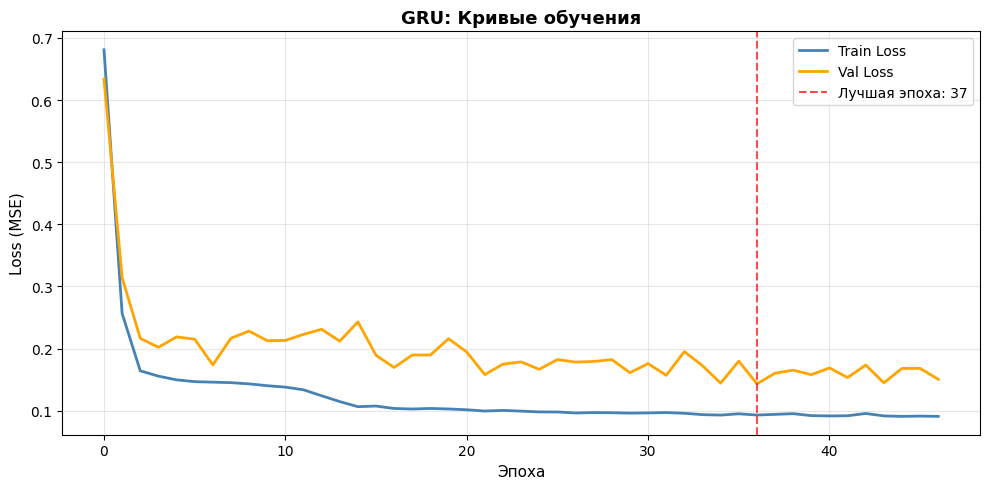


R1 (GRU) на валидации:
  MAE:  5.5396
  RMSE: 7.2095
  MAPE: 3.76%

R1 (GRU) на тесте:
  MAE:  6.7653
  RMSE: 8.7168
  MAPE: 4.40%


In [17]:
# 10. Обучение и оценка GRU

print("ЭКСПЕРИМЕНТ R1: GRU-forecast")

# Создание модели
model_r1 = GRUForecaster(
    input_size=1,
    hidden_size=64,
    num_layers=2,
    dropout=0.0
).to(device)

print(f"Модель GRU создана: {sum(p.numel() for p in model_r1.parameters()):,} параметров")

# Обучение
history_r1 = fit_model(
    model=model_r1,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=50,
    lr=5e-4,
    device=device
)

print(f"\n Обучение GRU завершено")
print(f"  Лучший валидационный loss: {min(history_r1['val_loss']):.4f}")

# Кривые обучения
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_r1["train_loss"], label="Train Loss", linewidth=2, color="steelblue")
ax.plot(history_r1["val_loss"], label="Val Loss", linewidth=2, color="orange")
ax.axvline(np.argmin(history_r1["val_loss"]), color="red", linestyle="--", 
           label=f"Лучшая эпоха: {np.argmin(history_r1['val_loss']) + 1}", alpha=0.7)
ax.set_title("GRU: Кривые обучения", fontsize=13, fontweight='bold')
ax.set_xlabel("Эпоха", fontsize=11)
ax.set_ylabel("Loss (MSE)", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Оценка на валидации и тесте
@torch.no_grad()
def evaluate_model(model, loader, scaler, device):
    """Оценка модели с инверсией нормализации."""
    model.eval()
    preds, targets = [], []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        pred = model(X_batch)
        preds.extend(pred.cpu().numpy())
        targets.extend(y_batch.cpu().numpy())

    preds_inv = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).ravel()
    targets_inv = scaler.inverse_transform(np.array(targets).reshape(-1, 1)).ravel()

    return preds_inv, targets_inv

# Оценка на валидации
preds_r1_val, targets_val = evaluate_model(model_r1, val_loader, scaler_gru, device)
metrics_r1_val = calculate_metrics(targets_val, preds_r1_val)

print(f"\nR1 (GRU) на валидации:")
print(f"  MAE:  {metrics_r1_val['mae']:.4f}")
print(f"  RMSE: {metrics_r1_val['rmse']:.4f}")
print(f"  MAPE: {metrics_r1_val['mape']:.2f}%")

# Оценка на тесте (один раз!)
preds_r1_test, targets_test = evaluate_model(model_r1, test_loader, scaler_gru, device)
metrics_r1_test = calculate_metrics(targets_test, preds_r1_test)

print(f"\nR1 (GRU) на тесте:")
print(f"  MAE:  {metrics_r1_test['mae']:.4f}")
print(f"  RMSE: {metrics_r1_test['rmse']:.4f}")
print(f"  MAPE: {metrics_r1_test['mape']:.2f}%")

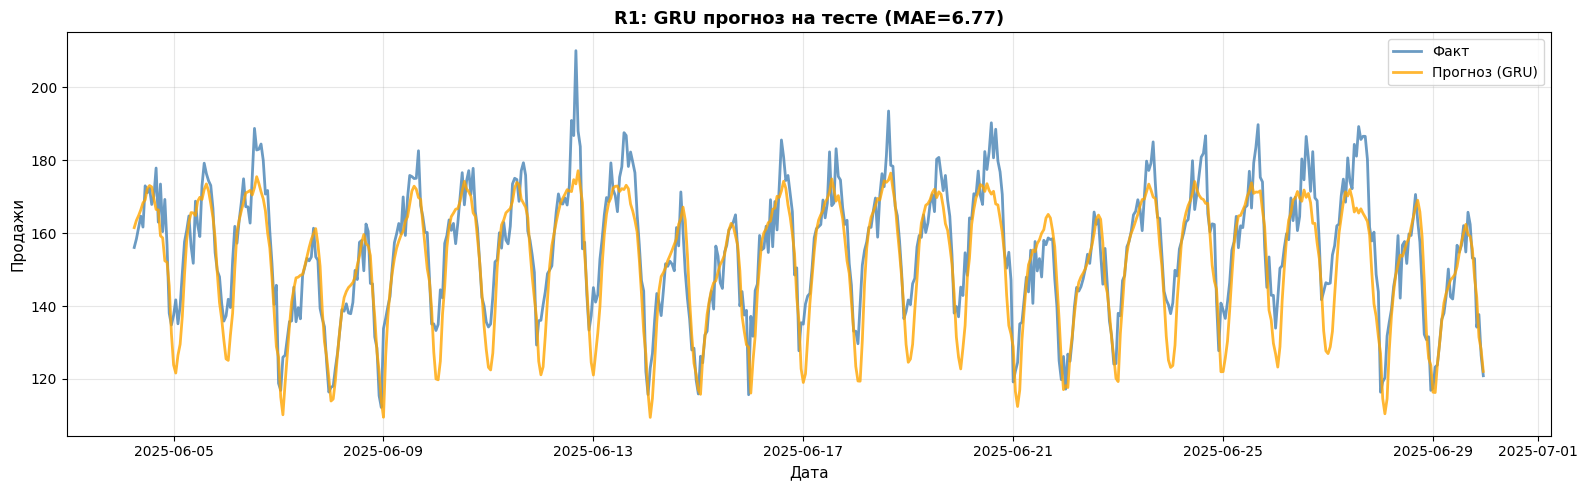

In [18]:

# 11. Визуализация прогноза

# Прогноз на тесте
test_dates = test_df["date"].iloc[window_size:].values

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(test_dates, targets_test, label="Факт", color="steelblue", linewidth=2, alpha=0.8)
ax.plot(test_dates, preds_r1_test, label="Прогноз (GRU)", color="orange", linewidth=2, alpha=0.8)
ax.set_title(f"R1: GRU прогноз на тесте (MAE={metrics_r1_test['mae']:.2f})", 
             fontsize=13, fontweight='bold')
ax.set_xlabel("Дата", fontsize=11)
ax.set_ylabel("Продажи", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# 12. Сохранение артефактов (ИСПРАВЛЕНО: использование None вместо пустых строк)

os.makedirs("artifacts", exist_ok=True)
os.makedirs("artifacts/figures", exist_ok=True)

# Сохранение модели
torch.save(model_r1.state_dict(), "artifacts/best_gru.pt")
print("Модель GRU сохранена в artifacts/best_gru.pt")

# Сохранение конфига с информацией о нормализации
config_r1 = {
    "model_type": "GRUForecaster",
    "input_size": 1,
    "hidden_size": 64,
    "num_layers": 2,
    "dropout": 0.0,
    "window_size": window_size,
    "horizon": 1,
    "batch_size": batch_size,
    "learning_rate": 5e-4,
    "epochs_trained": len(history_r1["train_loss"]),
    "best_val_loss": min(history_r1["val_loss"]),
    "best_val_mae": metrics_r1_val["mae"],
    "test_mae": metrics_r1_test["mae"],
    "seed": SEED,
    "device": str(device),
    "scaler": "StandardScaler",
    "normalization": {
        "type": "StandardScaler",
        "fit_on": "train target values only",
        "applied_to": "train, validation, test sets"
    }
}

with open("artifacts/best_gru_config.json", "w", encoding="utf-8") as f:
    json.dump(config_r1, f, indent=2, ensure_ascii=False)
print("Конфиг модели сохранён в artifacts/best_gru_config.json")

# Создание runs.csv с корректными типами данных (None вместо пустых строк)

split_summary_b = (
    f"{train_feat['date'].min().date()}→{train_feat['date'].max().date()}/"
    f"{val_feat['date'].min().date()}→{val_feat['date'].max().date()}/"
    f"{test_feat['date'].min().date()}→{test_feat['date'].max().date()}"
)

split_summary_r = (
    f"{train_df['date'].min().date()}→{train_df['date'].max().date()}/"
    f"{val_df['date'].min().date()}→{val_df['date'].max().date()}/"
    f"{test_df['date'].min().date()}→{test_df['date'].max().date()}"
)

# ИСПРАВЛЕНО: используем None для пустых числовых полей
runs_data = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary_b,
        "window_size": None,
        "horizon": 1,
        "model_summary": "naive-last",
        "features_summary": "lag_1",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": metrics_b1["mae"],
        "best_val_rmse": metrics_b1["rmse"],
        "best_val_mape": metrics_b1["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "forecast = last known value (lag_1)"
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary_b,
        "window_size": None,
        "horizon": 1,
        "model_summary": "moving-average",
        "features_summary": "rolling_mean_7",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": metrics_b2["mae"],
        "best_val_rmse": metrics_b2["rmse"],
        "best_val_mape": metrics_b2["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "forecast = rolling mean over 7 steps"
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary_b,
        "window_size": None,
        "horizon": 1,
        "model_summary": "ridge-lag-features",
        "features_summary": "lags [1,2,3,7,14,28], rolling [7,28], calendar",
        "scaler": "StandardScaler",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": metrics_b3["mae"],
        "best_val_rmse": metrics_b3["rmse"],
        "best_val_mape": metrics_b3["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Ridge regression on engineered features"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": split_summary_r,
        "window_size": window_size,
        "horizon": 1,
        "model_summary": "GRU (hidden_size=64, num_layers=2)",
        "features_summary": "target (windowed)",
        "scaler": "StandardScaler",
        "optimizer": "Adam",
        "lr": 5e-4,
        "epochs_trained": len(history_r1["train_loss"]),
        "best_val_mae": metrics_r1_val["mae"],
        "best_val_rmse": metrics_r1_val["rmse"],
        "best_val_mape": metrics_r1_val["mape"],
        "test_mae": metrics_r1_test["mae"],
        "test_rmse": metrics_r1_test["rmse"],
        "test_mape": metrics_r1_test["mape"],
        "notes": "GRU on windowed representation of time series"
    }
]

# Сохранение в CSV с кодировкой UTF-8
with open("artifacts/runs.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=runs_data[0].keys())
    writer.writeheader()
    writer.writerows(runs_data)

print("Результаты всех экспериментов сохранены в artifacts/runs.csv")

# Финальное сравнение (ИСПРАВЛЕНО: корректная проверка типа test_mae)

print("\n ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ")
runs_df = pd.DataFrame(runs_data)
comparison = runs_df[[
    "experiment_id", "model_summary", "best_val_mae", "best_val_rmse", "best_val_mape", "test_mae"
]].sort_values("best_val_mae")

print(comparison.to_string(index=False))

best_model = comparison.iloc[0]
print(f"\n Лучшая модель: {best_model['experiment_id']} ({best_model['model_summary']})")
print(f"   Лучший валидационный MAE: {best_model['best_val_mae']:.4f}")

# Корректная проверка наличия тестового MAE
if pd.notna(best_model['test_mae']):
    print(f"   Тестовый MAE: {best_model['test_mae']:.4f}")
else:
    print("   Тестовый MAE: не оценивался (только для лучшей модели)")

Модель GRU сохранена в artifacts/best_gru.pt
Конфиг модели сохранён в artifacts/best_gru_config.json
Результаты всех экспериментов сохранены в artifacts/runs.csv

 ФИНАЛЬНОЕ СРАВНЕНИЕ ВСЕХ МОДЕЛЕЙ
experiment_id                      model_summary  best_val_mae  best_val_rmse  best_val_mape  test_mae
           B3                 ridge-lag-features      5.148805       6.607749       3.453728       NaN
           R1 GRU (hidden_size=64, num_layers=2)      5.539616       7.209529       3.761801  6.765278
           B1                         naive-last      6.454645       8.239124       4.400688       NaN
           B2                     moving-average     12.734546      15.271722       8.837263       NaN

 Лучшая модель: B3 (ridge-lag-features)
   Лучший валидационный MAE: 5.1488
   Тестовый MAE: не оценивался (только для лучшей модели)
